d:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Loading model: ./models/traffic_sign_detection_gtsrb_updatedV2.h5
Model loaded (Keras).
Total rows in test.csv: 12630
Missing images: 0
Found 12630 valid test images to evaluate.


Predicting: 100%|██████████| 12630/12630 [00:13<00:00, 932.21it/s]



🎯 Overall Test Accuracy: 96.89%  (12630 images)


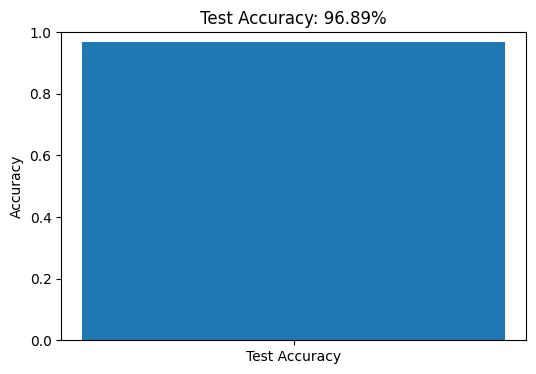

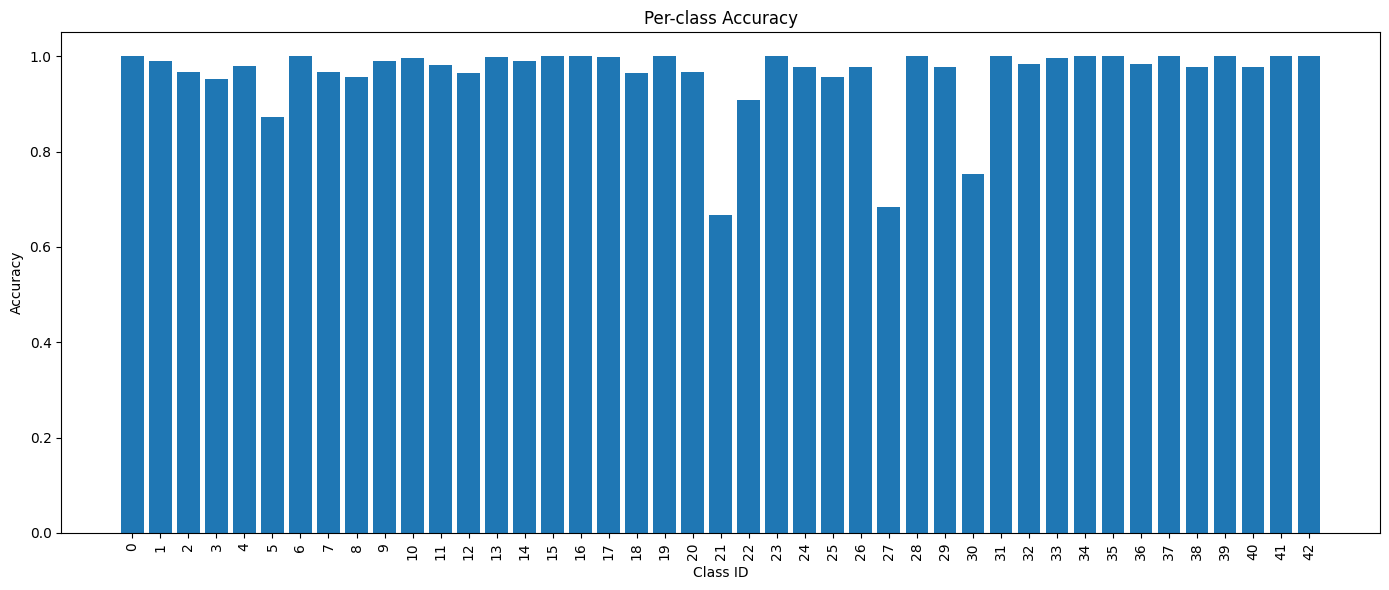


Classification Report:

              precision    recall  f1-score   support

           0     0.9524    1.0000    0.9756        60
           1     0.9037    0.9903    0.9450       720
           2     0.9603    0.9667    0.9635       750
           3     0.9794    0.9511    0.9651       450
           4     0.9893    0.9788    0.9840       660
           5     0.9632    0.8730    0.9159       630
           6     0.9554    1.0000    0.9772       150
           7     0.9775    0.9667    0.9721       450
           8     0.9931    0.9556    0.9740       450
           9     0.9694    0.9896    0.9794       480
          10     0.9925    0.9970    0.9947       660
          11     0.9604    0.9810    0.9706       420
          12     0.9652    0.9652    0.9652       690
          13     0.9986    0.9972    0.9979       720
          14     0.9889    0.9889    0.9889       270
          15     0.9211    1.0000    0.9589       210
          16     0.9677    1.0000    0.9836       150
  

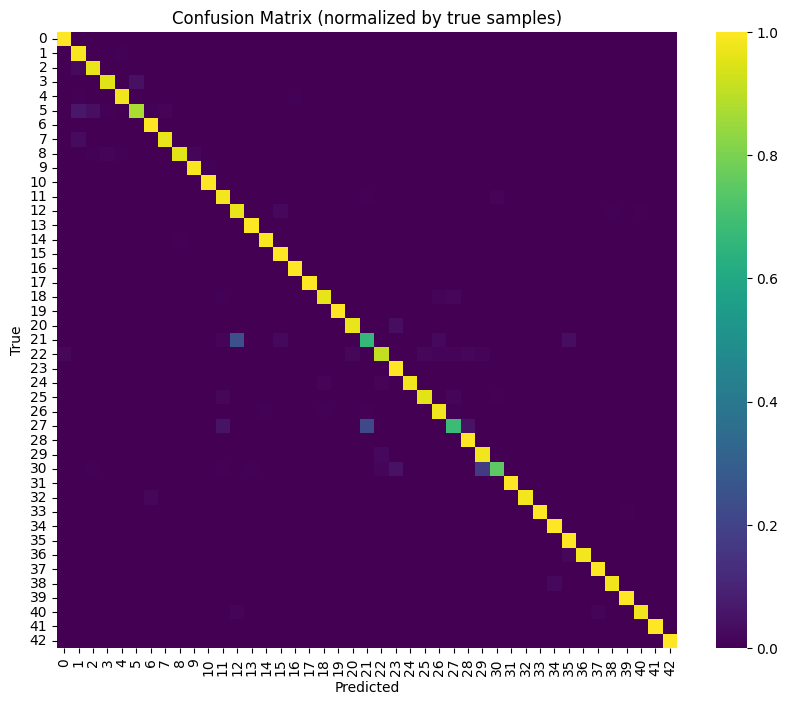

In [3]:
# REQUIREMENTS: tensorflow, pandas, numpy, matplotlib, pillow, sklearn, seaborn, tqdm (optional)
# e.g. pip install tensorflow pandas matplotlib pillow scikit-learn seaborn tqdm

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# ---------------- CONFIG ----------------
MODEL_PATH = "./models/traffic_sign_detection_gtsrb_updatedV2.h5"   # <-- change to your model path (.h5 or SavedModel dir)
DATA_ROOT = "./data"                       # root folder that contains test.csv and referenced image files
TEST_CSV = os.path.join(DATA_ROOT, "test.csv")
IMG_SIZE = (32, 32)                        # model input size (width, height)
BATCH_SIZE = 64
# ----------------------------------------

# 1) Load model
print("Loading model:", MODEL_PATH)
try:
    model = load_model(MODEL_PATH)
    print("Model loaded (Keras).")
except Exception as e:
    raise RuntimeError(f"Failed to load model at {MODEL_PATH}: {e}")

# 2) Read test.csv
if not os.path.exists(TEST_CSV):
    raise FileNotFoundError(f"Test CSV not found: {TEST_CSV}")

df = pd.read_csv(TEST_CSV)
expected_cols = {'Width','Height','Roi.X1','Roi.Y1','Roi.X2','Roi.Y2','ClassId','Path'}
if not expected_cols.issubset(set(df.columns)):
    print("Warning: test.csv missing some expected columns. Found columns:", df.columns.tolist())

print(f"Total rows in test.csv: {len(df)}")

# 3) Load images and true labels
def load_and_preprocess_image(img_path, roi=None, img_size=(32,32)):
    """
    Loads image (PIL), crops to roi if provided (x1,y1,x2,y2),
    resizes to img_size (width,height) and returns normalized numpy array (0..1).
    """
    img = Image.open(img_path).convert("RGB")
    if roi is not None:
        x1,y1,x2,y2 = roi
        # safeguard bounds as ints
        x1 = int(max(0, x1))
        y1 = int(max(0, y1))
        x2 = int(min(img.width, x2))
        y2 = int(min(img.height, y2))
        if x2 > x1 and y2 > y1:
            img = img.crop((x1, y1, x2, y2))
    # img = img.resize(img_size, Image.ANTIALIAS)
    img = img.resize(img_size, Image.Resampling.LANCZOS)

    arr = np.asarray(img).astype("float32") / 255.0
    return arr

image_paths = []
y_true = []
missing = 0

for idx, row in df.iterrows():
    rel_path = str(row['Path'])
    # sometimes Path might already be absolute, otherwise join with DATA_ROOT
    if os.path.isabs(rel_path):
        img_path = rel_path
    else:
        img_path = os.path.join(DATA_ROOT, rel_path)
    if not os.path.exists(img_path):
        # also try with Test folder if Path only contains filename
        alt = os.path.join(DATA_ROOT, "Test", os.path.basename(rel_path))
        if os.path.exists(alt):
            img_path = alt
        else:
            missing += 1
            image_paths.append(None)
            y_true.append(int(row['ClassId']))
            continue
    image_paths.append(img_path)
    y_true.append(int(row['ClassId']))

print(f"Missing images: {missing}")

# 4) Build X_test array in batches (to avoid memory blow if huge)
# We'll load and predict in batches to avoid needing to hold entire dataset if large.
valid_indices = [i for i,p in enumerate(image_paths) if p is not None]
n_total = len(valid_indices)
print(f"Found {n_total} valid test images to evaluate.")

# Helper to read ROI if present
def roi_from_row(row):
    try:
        x1 = int(row.get('Roi.X1', 0))
        y1 = int(row.get('Roi.Y1', 0))
        x2 = int(row.get('Roi.X2', 0))
        y2 = int(row.get('Roi.Y2', 0))
        # if all zeros, treat as None
        if (x1, y1, x2, y2) == (0,0,0,0):
            return None
        return (x1, y1, x2, y2)
    except Exception:
        return None

# Predict in batches
y_true_arr = np.array([y_true[i] for i in valid_indices], dtype=int)
preds = []
batch_imgs = []
batch_indices = []
for idx in tqdm(valid_indices, desc="Predicting"):
    row = df.iloc[idx]
    img_path = image_paths[idx]
    roi = roi_from_row(row)
    try:
        arr = load_and_preprocess_image(img_path, roi=roi, img_size=IMG_SIZE)
    except Exception as ex:
        print(f"Failed to load {img_path}: {ex}")
        arr = np.zeros((IMG_SIZE[1], IMG_SIZE[0], 3), dtype=np.float32)
    batch_imgs.append(arr)
    batch_indices.append(idx)
    # When batch full or last item: predict
    if len(batch_imgs) >= BATCH_SIZE:
        Xb = np.stack(batch_imgs, axis=0)
        y_prob = model.predict(Xb, verbose=0)
        if y_prob.ndim == 2 and y_prob.shape[1] > 1:
            y_pred_batch = np.argmax(y_prob, axis=1)
        else:
            y_pred_batch = (y_prob > 0.5).astype(int).ravel()
        preds.extend(y_pred_batch.tolist())
        batch_imgs = []
        batch_indices = []

# final batch
if len(batch_imgs) > 0:
    Xb = np.stack(batch_imgs, axis=0)
    y_prob = model.predict(Xb, verbose=0)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred_batch = np.argmax(y_prob, axis=1)
    else:
        y_pred_batch = (y_prob > 0.5).astype(int).ravel()
    preds.extend(y_pred_batch.tolist())

y_pred_arr = np.array(preds, dtype=int)
assert y_pred_arr.shape[0] == y_true_arr.shape[0]

# 5) Compute accuracy
overall_acc = (y_pred_arr == y_true_arr).mean()
print(f"\n🎯 Overall Test Accuracy: {overall_acc*100:.2f}%  ({y_pred_arr.shape[0]} images)")

# 6) Per-class accuracy
n_classes = max(int(y_true_arr.max()), int(y_pred_arr.max())) + 1
per_class_total = np.zeros(n_classes, dtype=int)
per_class_correct = np.zeros(n_classes, dtype=int)
for t,p in zip(y_true_arr, y_pred_arr):
    per_class_total[t] += 1
    if t == p:
        per_class_correct[t] += 1

per_class_acc = np.zeros(n_classes, dtype=float)
for i in range(n_classes):
    if per_class_total[i] > 0:
        per_class_acc[i] = per_class_correct[i] / per_class_total[i]
    else:
        per_class_acc[i] = np.nan

# 7) Plot overall accuracy (single bar) and per-class accuracy
plt.figure(figsize=(6,4))
plt.bar(["Test Accuracy"], [overall_acc])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title(f"Test Accuracy: {overall_acc*100:.2f}%")
plt.show()

# per-class plot (if many classes, increase size)
plt.figure(figsize=(14,6))
indices = np.arange(n_classes)
plt.bar(indices, per_class_acc)
plt.xlabel("Class ID")
plt.ylabel("Accuracy")
plt.title("Per-class Accuracy")
plt.ylim(0,1.05)
plt.xticks(indices, indices, rotation=90)
plt.tight_layout()
plt.show()

# 8) Confusion matrix and classification report (for classes present)
cm = confusion_matrix(y_true_arr, y_pred_arr, labels=np.arange(n_classes))
print("\nClassification Report:\n")
print(classification_report(y_true_arr, y_pred_arr, digits=4))

plt.figure(figsize=(10,8))
# normalize for better visualization (by true label counts)
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)
sns.heatmap(cm_norm, annot=False, cmap='viridis')
plt.title("Confusion Matrix (normalized by true samples)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
